=== 1. Pengecekan Direktori dan File ===
Direktori kerja saat ini: c:\Patrick\coding\save later\spect

File 'demographics.csv' DITEMUKAN. Ukuran: 1865026 bytes

Mengintip 3 baris pertama teks asli (raw text) di dalam file:
Baris 1: Tag,Keyword,Value;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
Baris 2: (0008, 0005),SpecificCharacterSet,ISO_IR 100;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;...
Baris 3: "(0008, 0008),ImageType,""['ORIGINAL', 'PRIMARY', 'RECON TOMO', 'EMISSION']""";;;;;;;;;;;;;;;;;;;;;;...


=== 2. Membaca Metadata DICOM yang Sudah Diperbaiki ===
Berhasil! Berikut 10 baris pertama metadata yang sudah bersih:
          Tag               Keyword  \
(0008   0005)  SpecificCharacterSet   
(0008   0016)           SOPClassUID   
(0008   0018)        SOPInstanceUID   
(0008   0020)             StudyDate   
(0008   0022)       AcquisitionDate   
(0008   0023)           ContentDate   
(0008   0030)             StudyTime   
(0008

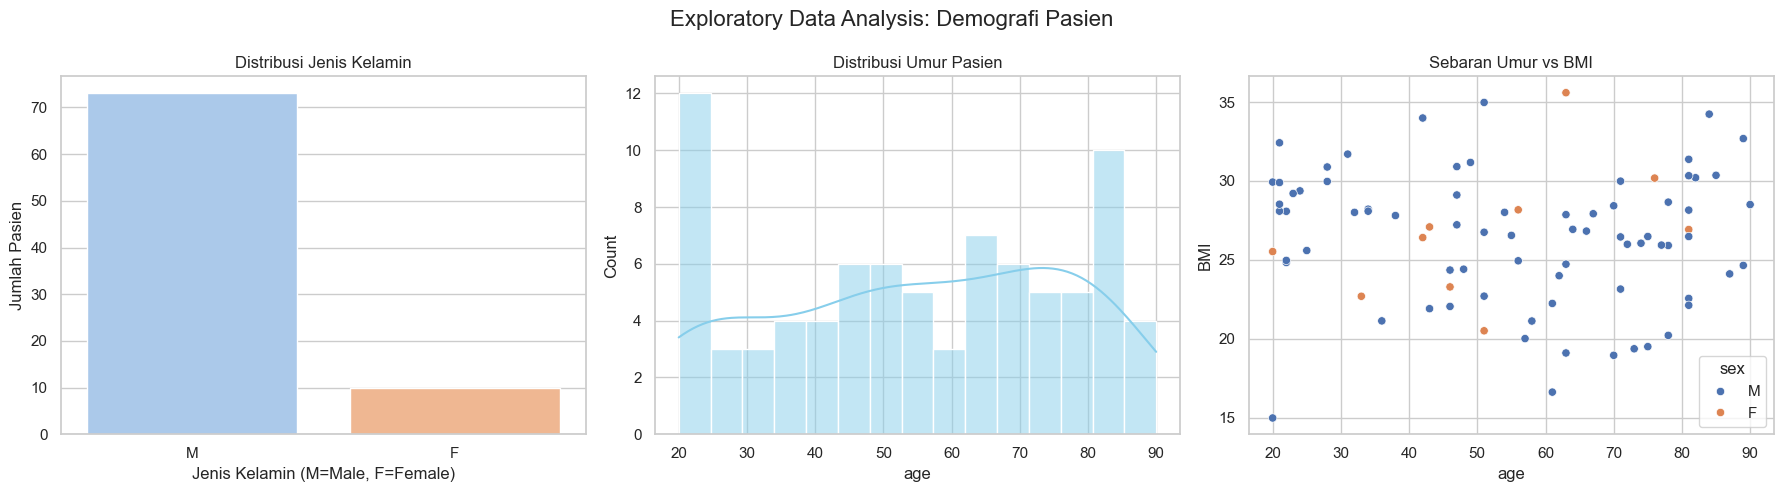

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("=== 1. Pengecekan Direktori dan File ===")
print(f"Direktori kerja saat ini: {os.getcwd()}")

file_target = 'demographics.csv'

if os.path.exists(file_target):
    print(f"\nFile '{file_target}' DITEMUKAN. Ukuran: {os.path.getsize(file_target)} bytes")
    print("\nMengintip 3 baris pertama teks asli (raw text) di dalam file:")
    with open(file_target, 'r', encoding='utf-8', errors='ignore') as f:
        for i in range(3):
            # Print sebagian karakter saja agar tidak memenuhi layar jika titik komanya terlalu panjang
            print(f"Baris {i+1}: {f.readline().strip()[:100]}...") 
else:
    print(f"\n[ERROR] File '{file_target}' TIDAK DITEMUKAN di direktori ini!")
    print("Pastikan file berada di folder yang sama dengan skrip ini.")

print("\n" + "="*50 + "\n")

print("=== 2. Membaca Metadata DICOM yang Sudah Diperbaiki ===")
try:
    if os.path.exists(file_target):
        # 1. Baca menggunakan pemisah koma (,). Karena kolom 3 punya banyak titik koma, kita batasi ambil 3 kolom pertama saja
        df_meta = pd.read_csv(file_target, sep=',', usecols=[0, 1, 2], on_bad_lines='skip', engine='python')
        
        # 2. Bersihkan nama kolom dari spasi atau karakter aneh
        df_meta.columns = df_meta.columns.str.strip()
        
        # 3. Kolom ke-3 ('Value') tertempel banyak titik koma (misal: 'ISO_IR 100;;;;;'). Kita hapus titik komanya.
        if 'Value' in df_meta.columns:
            df_meta['Value'] = df_meta['Value'].astype(str).str.replace(';', '', regex=False).str.strip()
        
        print("Berhasil! Berikut 10 baris pertama metadata yang sudah bersih:")
        print(df_meta.head(10))
except Exception as e:
    print(f"Gagal membaca file: {e}")

print("\n" + "="*50 + "\n")

# 3. FIX WARNING SEABORN (Template EDA Pasien)
print("=== 3. Template EDA Demografi Pasien (Fix Warning Seaborn) ===")
import numpy as np
np.random.seed(42)
df_patients = pd.DataFrame({
    'patient_id': [f'P{str(i).zfill(3)}' for i in range(1, 84)],
    'sex': np.random.choice(['M', 'F'], size=83, p=[0.88, 0.12]),
    'age': np.random.randint(20, 91, size=83),
    'BMI': np.random.normal(26.5, 4.0, size=83)
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis: Demografi Pasien', fontsize=16)

sns.countplot(data=df_patients, x='sex', hue='sex', palette='pastel', legend=False, ax=axes[0])
axes[0].set_title('Distribusi Jenis Kelamin')
axes[0].set_xlabel('Jenis Kelamin (M=Male, F=Female)')
axes[0].set_ylabel('Jumlah Pasien')

sns.histplot(data=df_patients, x='age', bins=15, kde=True, color='skyblue', ax=axes[1])
axes[1].set_title('Distribusi Umur Pasien')

sns.scatterplot(data=df_patients, x='age', y='BMI', hue='sex', palette='deep', ax=axes[2])
axes[2].set_title('Sebaran Umur vs BMI')

plt.tight_layout()
plt.show()

In [3]:
import os
import pandas as pd
import re # Menggunakan regex untuk pembersihan ekstra

# 2. CARA IMPORT YANG BENAR UNTUK DEMOGRAPHICS.CSV (Revisi)
print("=== 2. Membaca Metadata DICOM yang Sudah Diperbaiki ===")
file_target = 'demographics.csv'

try:
    if os.path.exists(file_target):
        # 1. Baca data
        df_meta = pd.read_csv(file_target, sep=',', usecols=[0, 1, 2], on_bad_lines='skip', engine='python')
        
        # 2. Bersihkan nama kolom
        df_meta.columns = [col.strip() for col in df_meta.columns]
        
        # 3. Rename kolom agar mudah dipanggil (opsional, tapi disarankan)
        df_meta.rename(columns={'Value;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;': 'Value'}, inplace=True)
        
        # 4. Pembersihan tingkat lanjut pada kolom 'Value'
        if 'Value' in df_meta.columns:
            # Gunakan regex untuk membuang semua semicolon di akhir string
            df_meta['Value'] = df_meta['Value'].apply(lambda x: re.sub(r';+$', '', str(x)).strip())
            
        # 5. Tampilkan hasilnya (batasi lebar kolom agar rapi di terminal)
        pd.set_option('display.max_colwidth', 50) 
        print("Berhasil! Berikut 10 baris pertama metadata yang sudah bersih:\n")
        print(df_meta.head(10).to_string(index=False)) # Hilangkan index angka di kiri

except Exception as e:
    print(f"Gagal membaca atau memproses file: {e}")

print("\n" + "="*50 + "\n")

=== 2. Membaca Metadata DICOM yang Sudah Diperbaiki ===
Berhasil! Berikut 10 baris pertama metadata yang sudah bersih:

   Tag              Keyword                                                   Value
 0005) SpecificCharacterSet                                              ISO_IR 100
 0016)          SOPClassUID                              1.2.840.10008.5.1.4.1.1.20
 0018)       SOPInstanceUID 1.2.840.4267.32.102843376980518437893525476318362476257
 0020)            StudyDate                                                20230122
 0022)      AcquisitionDate                                                20230122
 0023)          ContentDate                                                20230122
 0030)            StudyTime                                                        
 0033)          ContentTime                                                        
 0050)      AccessionNumber                                        1131169481093355
 0060)             Modality             

In [4]:
import pandas as pd

# Asumsi df_meta sudah terbaca dan dibersihkan dari kode sebelumnya

print("=== Mencari Informasi Demografi & Klinis Spesifik ===")

# 1. Cari semua baris yang Keyword-nya mengandung kata 'Patient'
print("\n1. Data yang mengandung kata 'Patient':")
patient_data = df_meta[df_meta['Keyword'].str.contains('Patient', na=False, case=False)]
if not patient_data.empty:
    print(patient_data[['Keyword', 'Value']].to_string(index=False))
else:
    print("Tidak ditemukan data terkait 'Patient'.")

# 2. Cari info klinis lainnya (seperti jenis radioaktif yang disuntikkan atau pabrikan alat)
print("\n2. Data Klinis / Mesin:")
clinical_keywords = ['Radiopharmaceutical', 'Manufacturer', 'DetectorType', 'PatientWeight']
clinical_data = df_meta[df_meta['Keyword'].isin(clinical_keywords)]
if not clinical_data.empty:
    print(clinical_data[['Keyword', 'Value']].to_string(index=False))
else:
    print("Tidak ditemukan data klinis spesifik tersebut.")

=== Mencari Informasi Demografi & Klinis Spesifik ===

1. Data yang mengandung kata 'Patient':
               Keyword                                   Value
           PatientName 169973109456972001538896041185181700077
             PatientID   5782312949390211736691483375399594768
      PatientBirthDate                                19681022
            PatientSex                                        
PatientIdentityRemoved                                     YES
       PatientPosition                                     FFS

2. Data Klinis / Mesin:
     Keyword              Value
Manufacturer GE MEDICAL SYSTEMS


=== EDA Cross-Format: DICOM (Raw) + NIfTI (Mask) ===
Total File Gambar DICOM : 103
Total File Label NIfTI  : 100

Sukses menemukan pasangan data!
  Raw Image (DICOM): 1.2.840.4267.32.102843376980518437893525476318362476257.dcm
  Label Mask (NIfTI): 1.2.840.4267.32.102843376980518437893525476318362476257_mask.nii.gz

Shape Asli DICOM : (50, 70, 70)
Shape Asli NIfTI : (70, 70, 50)


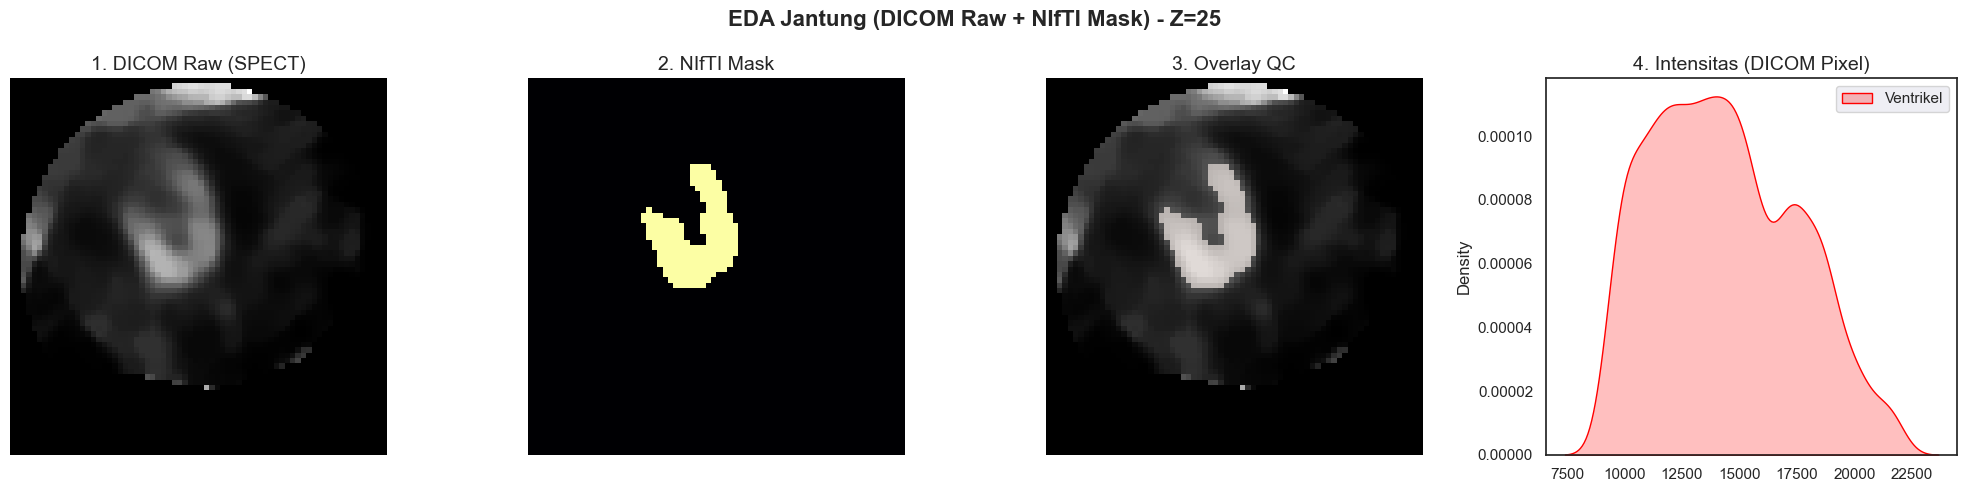

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import nibabel as nib
    import pydicom
except ImportError:
    print("\n[ERROR] Library belum lengkap.")
    print("Jalankan di terminal: pip install pydicom nibabel matplotlib seaborn numpy")
    exit()

TARGET_DIR = r"c:\Patrick\coding\save later\spect"
DICOM_DIR = os.path.join(TARGET_DIR, "DICOM")
NIFTI_DIR = os.path.join(TARGET_DIR, "NIfTI")

print(f"=== EDA Cross-Format: DICOM (Raw) + NIfTI (Mask) ===")

mask_files = glob.glob(os.path.join(NIFTI_DIR, "*_mask.nii.gz"))
dicom_files = glob.glob(os.path.join(DICOM_DIR, "*.dcm"))

print(f"Total File Gambar DICOM : {len(dicom_files)}")
print(f"Total File Label NIfTI  : {len(mask_files)}\n")

if not mask_files or not dicom_files:
    print("[ERROR] Folder DICOM atau NIfTI tidak ditemukan/kosong.")
else:
    # 1. Ambil sampel mask pertama
    sample_mask_path = mask_files[0]
    
    # 2. Ekstrak Base ID (Menghapus folder dan '_mask.nii.gz')
    base_id = os.path.basename(sample_mask_path).replace("_mask.nii.gz", "")
    
    # 3. Cari file DICOM dengan ID yang sama
    sample_dicom_path = os.path.join(DICOM_DIR, f"{base_id}.dcm")
    
    if not os.path.exists(sample_dicom_path):
        print(f"[ERROR] Tidak menemukan file DICOM pasangan untuk ID: {base_id}")
    else:
        print(f"Sukses menemukan pasangan data!")
        print(f"  Raw Image (DICOM): {os.path.basename(sample_dicom_path)}")
        print(f"  Label Mask (NIfTI): {os.path.basename(sample_mask_path)}\n")
        
        # 2. MEMBACA VOLUME 3D (DICOM & NIFTI)
        # Baca DICOM (Biasanya bentuknya Z, X, Y atau Z, Y, X)
        dicom_data = pydicom.dcmread(sample_dicom_path)
        img_volume = dicom_data.pixel_array
        
        # Baca NIfTI (Biasanya bentuknya X, Y, Z)
        mask_volume = nib.load(sample_mask_path).get_fdata()
        
        print(f"Shape Asli DICOM : {img_volume.shape}")
        print(f"Shape Asli NIfTI : {mask_volume.shape}")
        
        # Karena DICOM dan NIfTI sering beda orientasi sumbu (ZXY vs XYZ), 
        # kita sesuaikan agar Z (kedalaman/jumlah irisan) ada di indeks terakhir
        if img_volume.shape[0] == mask_volume.shape[2]: 
            # Ubah orientasi (Z, Y, X) -> (X, Y, Z) atau sejenisnya tergantung data
            img_volume = np.transpose(img_volume, (2, 1, 0))
            
        # Ambil irisan tengah
        mid_z = mask_volume.shape[2] // 2
        
        # Ekstrak irisan 2D
        img_slice = img_volume[:, :, mid_z]
        mask_slice = mask_volume[:, :, mid_z]
        
        sns.set_theme(style="white")
        fig, axes = plt.subplots(1, 4, figsize=(20, 5))
        fig.suptitle(f'EDA Jantung (DICOM Raw + NIfTI Mask) - Z={mid_z}', fontsize=16, fontweight='bold')
        
        axes[0].imshow(img_slice.T, cmap='gray', origin='lower')
        axes[0].set_title('1. DICOM Raw (SPECT)', fontsize=14)
        axes[0].axis('off')
        
        axes[1].imshow(mask_slice.T, cmap='inferno', origin='lower')
        axes[1].set_title('2. NIfTI Mask', fontsize=14)
        axes[1].axis('off')
        
        axes[2].imshow(img_slice.T, cmap='gray', origin='lower')
        mask_overlay = np.ma.masked_where(mask_slice.T == 0, mask_slice.T)
        axes[2].imshow(mask_overlay, cmap='Reds', alpha=0.6, origin='lower')
        axes[2].set_title('3. Overlay QC', fontsize=14)
        axes[2].axis('off')
        
        sns.set_theme(style="darkgrid")
        # Flatten array untuk histogram (pastikan dimensi sama sebelum masking)
        try:
            organ_voxels = img_volume[mask_volume == 1]
            if len(organ_voxels) > 0:
                sns.kdeplot(organ_voxels, color='red', fill=True, label='Ventrikel', ax=axes[3])
                
            axes[3].set_title('4. Intensitas (DICOM Pixel)', fontsize=14)
            axes[3].legend()
        except IndexError:
            axes[3].text(0.5, 0.5, "Dimensi DICOM & NIfTI berbeda,\ntidak bisa di-overlay langsung.", 
                         ha='center', va='center')
        
        plt.tight_layout()
        plt.show()

In [2]:
import os
import glob
import numpy as np

try:
    import nibabel as nib
    import pydicom
except ImportError:
    print("\n[ERROR] Library belum lengkap.")
    print("Jalankan di terminal: pip install pydicom nibabel numpy")
    exit()

TARGET_DIR = r"c:\Patrick\coding\save later\spect"
DICOM_DIR = os.path.join(TARGET_DIR, "DICOM")
# Folder output baru khusus untuk raw data nnU-Net
OUTPUT_DIR = os.path.join(TARGET_DIR, "nnUNet_Raw_Data")

# Membuat folder output jika belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"=== Konversi DICOM ke nnU-Net NIfTI ===")
print(f"Mencari file DICOM di: {DICOM_DIR}")

dicom_files = glob.glob(os.path.join(DICOM_DIR, "*.dcm"))

if not dicom_files:
    print("[ERROR] Tidak ada file DICOM ditemukan!")
    exit()

print(f"Ditemukan {len(dicom_files)} file DICOM. Memulai konversi...\n")

berhasil = 0
gagal = 0

for i, dicom_path in enumerate(dicom_files):
    filename = os.path.basename(dicom_path)
    base_id = filename.replace(".dcm", "")
    
    # Format nama output nnU-Net: <ID_PASIEN>_0000.nii.gz
    output_filename = f"{base_id}_0000.nii.gz"
    output_path = os.path.join(OUTPUT_DIR, output_filename)
    
    # Menampilkan progres setiap 10 file
    if (i + 1) % 10 == 0 or i == 0 or i == len(dicom_files) - 1:
        print(f"Memproses {i+1}/{len(dicom_files)}: {output_filename}")
    
    try:
        # 1. Membaca DICOM
        dicom_data = pydicom.dcmread(dicom_path)
        img_volume = dicom_data.pixel_array
        
        # Konversi tipe data ke float32 (standar umum untuk nnU-Net)
        img_volume = img_volume.astype(np.float32)
        
        # 2. Penyesuaian Orientasi Matriks (Z, Y, X -> X, Y, Z)
        # Berdasarkan temuan EDA sebelumnya
        if img_volume.ndim == 3:
            img_volume = np.transpose(img_volume, (2, 1, 0))
            
        # 3. Membuat Objek NIfTI
        # Menggunakan affine identitas (matriks diagonal) karena affine aslinya hilang
        # nnU-Net cukup pintar untuk menangani ini asalkan konsisten dengan labelnya
        affine = np.eye(4) 
        nifti_img = nib.Nifti1Image(img_volume, affine)
        
        # 4. Menyimpan file _0000.nii.gz
        nib.save(nifti_img, output_path)
        berhasil += 1
        
    except Exception as e:
        print(f"  [GAGAL] Error memproses {filename}: {e}")
        gagal += 1

print("\n" + "="*50)
print("=== KONVERSI SELESAI ===")
print(f"Total file diproses : {len(dicom_files)}")
print(f"Berhasil dikonversi : {berhasil}")
print(f"Gagal/Error         : {gagal}")
print(f"Lokasi Output       : {OUTPUT_DIR}")
print("="*50)
print("File _0000.nii.gz Anda kini siap digunakan untuk model nnU-Net!")

=== Konversi DICOM ke nnU-Net NIfTI ===
Mencari file DICOM di: c:\Patrick\coding\save later\spect\DICOM
Ditemukan 103 file DICOM. Memulai konversi...

Memproses 1/103: 1.2.840.4267.32.102843376980518437893525476318362476257_0000.nii.gz
Memproses 10/103: 1.2.840.4267.32.127827035686297613630763372165567674198_0000.nii.gz
Memproses 20/103: 1.2.840.4267.32.167476230193563309132196922692220701328_0000.nii.gz
Memproses 30/103: 1.2.840.4267.32.196603754315238442466758987307782156865_0000.nii.gz
Memproses 40/103: 1.2.840.4267.32.234023661153270628251147618035939876800_0000.nii.gz
Memproses 50/103: 1.2.840.4267.32.254750163383645624454229702879463814937_0000.nii.gz
Memproses 60/103: 1.2.840.4267.32.270294565345733831828857310295354635209_0000.nii.gz
Memproses 70/103: 1.2.840.4267.32.301795709551910081580275003635965677844_0000.nii.gz
Memproses 80/103: 1.2.840.4267.32.337337333580442195354269464264232457083_0000.nii.gz
Memproses 90/103: 1.2.840.4267.32.67190153647569644119222304337334187527_000

In [ ]:
import os
import glob
import shutil
import json

TARGET_DIR = r"c:\Patrick\coding\save later\spect"
NNUNET_RAW_DIR = os.path.join(TARGET_DIR, "nnUNet_Raw_Data") # Folder hasil konversi tadi
NIFTI_MASK_DIR = os.path.join(TARGET_DIR, "NIfTI")           # Folder mask asli

# Folder final sesuai standar nnU-Net v2
DATASET_NAME = "Dataset101_HeartSPECT"
FINAL_DIR = os.path.join(TARGET_DIR, DATASET_NAME)
IMAGES_TR = os.path.join(FINAL_DIR, "imagesTr")
LABELS_TR = os.path.join(FINAL_DIR, "labelsTr")

print(f"=== Membangun Struktur Folder nnU-Net ===")

os.makedirs(IMAGES_TR, exist_ok=True)
os.makedirs(LABELS_TR, exist_ok=True)

# 1. Cari semua mask
mask_files = glob.glob(os.path.join(NIFTI_MASK_DIR, "*_mask.nii.gz"))
print(f"Ditemukan {len(mask_files)} file label/mask.")

berhasil_dipindah = 0

# 2. Pindahkan dan Rename
for mask_path in mask_files:
    # Nama asli mask: 1.2.840..._mask.nii.gz
    mask_filename = os.path.basename(mask_path)
    base_id = mask_filename.replace("_mask.nii.gz", "")
    
    # Path gambar raw yang sudah dikonversi: 1.2.840..._0000.nii.gz
    raw_img_filename = f"{base_id}_0000.nii.gz"
    raw_img_path = os.path.join(NNUNET_RAW_DIR, raw_img_filename)
    
    # Path tujuan
    dest_img_path = os.path.join(IMAGES_TR, raw_img_filename)
    # nnU-Net meminta nama label persis dengan raw, tapi TANPA _0000
    dest_mask_path = os.path.join(LABELS_TR, f"{base_id}.nii.gz") 
    
    if os.path.exists(raw_img_path):
        # Gunakan shutil.copy untuk menyalin (agar data asli tetap aman)
        shutil.copy(raw_img_path, dest_img_path)
        shutil.copy(mask_path, dest_mask_path)
        berhasil_dipindah += 1
    else:
        print(f"[WARNING] Raw image tidak ditemukan untuk: {raw_img_filename}")

print(f"Berhasil merakit {berhasil_dipindah} pasang data training.")

print("\nMembuat file dataset.json...")

dataset_json = {
    "name": "HeartSPECT",
    "description": "Myocardial Perfusion Scintigraphy (MPS) Image Database",
    "reference": "Calixto et al., PhysioNet",
    "licence": "ODbL",
    "release": "1.0.0",
    "tensorImageSize": "3D",
    "channel_names": {
        "0": "SPECT"
    },
    "labels": {
        "background": 0,
        "left_ventricular_wall": 1
    },
    "numTraining": berhasil_dipindah,
    "file_ending": ".nii.gz"
}

json_path = os.path.join(FINAL_DIR, "dataset.json")
with open(json_path, 'w') as f:
    json.dump(dataset_json, f, indent=4)

print("="*50)
print(f"STRUKTUR NNU-NET SELESAI!")
print(f"Folder Dataset Anda: {FINAL_DIR}")
print("="*50)
print("\nLangkah selanjutnya (di terminal Linux/WSL tempat Anda menginstal nnU-Net):")
print(f"nnUNetv2_plan_and_preprocess -d 101 --verify_dataset_integrity")

=== Membangun Struktur Folder nnU-Net ===
Ditemukan 100 file label/mask.
Berhasil merakit 100 pasang data training.

Membuat file dataset.json...
STRUKTUR NNU-NET SELESAI!
Folder Dataset Anda: c:\Patrick\coding\save later\spect\Dataset101_HeartSPECT

Langkah selanjutnya (di terminal Linux/WSL tempat Anda menginstal nnU-Net):
nnUNetv2_plan_and_preprocess -d 101 --verify_dataset_integrity
